## Utilisation d'un PINN comme méthode d'inversion

In [1]:
import jax
import jax.numpy as jnp
import functools
import numpy as np
import optax
import matplotlib.pyplot as plt
from data_load import WaveguideBoundaryData

In [2]:
print(jax.devices())

[CpuDevice(id=0)]


**Data loading**

In [3]:
#Domaine Omega : [-1,1]x[0,0.6]
#conditions de neuman en y=0 et y=0.6
H = 0.6
L = 1

data_loader_left = WaveguideBoundaryData('data/pinn_boundary_left_n0.csv')
data_loader_right = WaveguideBoundaryData('data/pinn_boundary_right_n0.csv')

X_left, Y_left, U_re_left, U_im_left, freq = data_loader_left.get_training_data()
X_right, Y_right, U_re_right, U_im_right, _ = data_loader_right.get_training_data()

Y_left = Y_left[freq[0]]
Y_right = Y_right[freq[0]]

**Normalisation des outputs et inputs**

In [4]:
# x est déjà dans [-1,1]
#on passe y et u au bord dans [-1,1]

Y_norm = jnp.max(Y_left)
Y_left=2*Y_left/Y_norm - 1
Y_right=2*Y_right/Y_norm - 1

U_norm = {}
U_left_norm = {}
U_right_norm = {}

for f in freq:
    U_norm[f] = np.sqrt(jnp.max(np.concatenate((U_re_left[f]**2 + U_im_left[f]**2,U_re_right[f]**2 + U_im_right[f]**2))))
    U_re_left[f]/=U_norm[f]
    U_im_left[f]/=U_norm[f]
    U_re_right[f]/=U_norm[f]
    U_im_right[f]/=U_norm[f]
    U_left_norm[f] = jnp.stack([U_re_left[f],U_im_left[f]], axis=1)
    U_right_norm[f] = jnp.stack([U_re_right[f],U_im_right[f]], axis=1)

**Initialisation des paramètres**

In [5]:
key = jax.random.key(0) # initialisation de la PRNG

#Initialisation des Fouriers Features
#On connait notre kmax car c0 = 340
fmax = jnp.max(freq.astype(np.float32))
c0 = 340
contrast = 1 #pour l'instant
kmax = 2*jnp.pi*fmax*contrast/340
m = 10

key, subkey = jax.random.split(key)
B = jax.random.uniform(subkey, (m, 2), minval=-kmax, maxval=kmax)

def gamma(x,y):
    v = jnp.array([x,y])
    return jnp.concatenate([jnp.cos(2*np.pi*B@v),jnp.sin(2*np.pi*B@v)])

#Il faut initialiser les points de quadratures

N_modes = int(np.round(2*H*fmax/c0)) + 5

n_gauss_legendre = 20

y_gauss_legendre, w_gauss_legendre = np.polynomial.legendre.leggauss(n_gauss_legendre)

# Entrée (x, y)
n_input = 2

n_layers_uv = [2*m, 64, 64, 64, 2]
n_layers_c = [n_input, 64, 1]

#Initialisation de Xavier

def init_layers(key, n_layers):
    layers = []
    for i in range(len(n_layers)-1):
        key, subkey = jax.random.split(key)
        W = jax.random.normal(subkey, (n_layers[i], n_layers[i+1])) / jnp.sqrt(n_layers[i])
        b = jnp.zeros(n_layers[i+1])
        layers.append({"W": W, "b": b})
    return layers, key

key, subkey_uv, subkey_c = jax.random.split(key, 3)

layers_uv, key = init_layers(subkey_uv, n_layers_uv)
layers_c, key = init_layers(subkey_c, n_layers_c)

# On regroupe les 3 réseaux dans le dictionnaire params
params = {
    "layers_uv": layers_uv,
    "layers_c": layers_c,
}

**Le Forward**

In [6]:
def forward_func(layers,X):
    n = len(layers)
    Z = X
    for i in range(n-1):
        Z = jax.nn.tanh(Z @ layers[i]["W"] + layers[i]["b"])
    Z = Z @ layers[-1]["W"] + layers[-1]["b"]
    return Z

def forward_params(layers,X):
    n = len(layers)
    Z = X
    for i in range(n-1):
        Z = jax.nn.tanh(Z @ layers[i]["W"] + layers[i]["b"])
    Z =jax.nn.softplus(Z @ layers[-1]["W"] + layers[-1]["b"])
    return Z

**La loss function**

In [7]:
y_quad = (y_gauss_legendre + 1.0) * H / 2.0
w_quad = w_gauss_legendre * H / 2.0
n_modes = jnp.arange(N_modes)
a_n = jnp.sqrt(2/H) * jnp.ones(N_modes)
a_n = a_n.at[0].set(jnp.sqrt(1/H))
C_quad = a_n[:, None] * jnp.cos(n_modes[:, None] * jnp.pi * y_quad[None, :] / H)

def loss_fn(params, x, y, f, target_u_left, target_u_right, y_bnd_left, y_bnd_right, u_norm_val):

    def uv(x,y):
        features = gamma(x, y)
        return forward_func(params["layers_uv"], features)
    
    def k(x,y):
        return 2*jnp.pi*f/forward_params(params["layers_c"], jnp.array([x, y]))
    
    def uv_x(x, y):
        return jax.jacfwd(uv, argnums=0)(x, y)

    def pde_residual(x, y):
        uv_xx = jax.jacfwd(jax.jacfwd(uv, argnums=0), argnums=0)(x, y)
        uv_yy = jax.jacfwd(jax.jacfwd(uv, argnums=1), argnums=1)(x, y)*(2/H)**2
        return uv_xx + uv_yy + k(x,y)**2*uv(x,y)
    
    k0 = 2*jnp.pi*f/c0

    beta_n = jnp.sqrt(k0**2 - (n_modes*jnp.pi/H)**2 +0j)
    
    def compute_dtn_loss(x_bnd, y_data, sign, A_inc=None):
        uv_quad = jax.vmap(uv, in_axes=(None, 0))(x_bnd, y_gauss_legendre)
        U_quad_complex = uv_quad[:, 0] + 1j * uv_quad[:, 1]
        
        u_n = C_quad @ (w_quad * U_quad_complex)
        
        dtn_n = sign * 1j * beta_n * u_n
        if A_inc is not None:
            dtn_n = dtn_n + 2j * beta_n * A_inc
        
        def DtN_eval(y_eval):
            C_y = a_n * jnp.cos(n_modes * jnp.pi * (y_eval+1)/2)
            return C_y @ dtn_n
            
        dtn_pred_complex = jax.vmap(DtN_eval)(y_data)
        
        dtn_actual = jax.vmap(uv_x, in_axes=(None, 0))(x_bnd, y_data)
        dtn_actual_complex = dtn_actual[:, 0] + 1j * dtn_actual[:, 1]
        
        return jnp.mean(jnp.abs(dtn_pred_complex - dtn_actual_complex)**2)

    A_inc_left = jnp.zeros(N_modes, dtype=jnp.complex64)
    amplitude_incidente = jnp.exp(-1j * beta_n[0] * L) / u_norm_val
    A_inc_left = A_inc_left.at[0].set(amplitude_incidente)
    
    vmap_pde_residual = jax.vmap(pde_residual, in_axes=(0, 0))
    pde_loss = jnp.mean(vmap_pde_residual(x, y)**2)

    dtn_loss_left = compute_dtn_loss(-1.0, y, sign=-1, A_inc=A_inc_left)
    dtn_loss_right = compute_dtn_loss(1.0, y, sign=1, A_inc=None)

    dtn_loss = dtn_loss_left + dtn_loss_right

    vmap_uv_y = jax.vmap(uv, (None,0))
    data_loss = jnp.mean((vmap_uv_y(-1.0,y_bnd_left) - target_u_left)**2+(vmap_uv_y(1.0,y_bnd_right) - target_u_right)**2)
    
    total_loss = pde_loss + dtn_loss + data_loss
    
    return total_loss, (pde_loss, dtn_loss, data_loss)

**Le training**

In [8]:
lr = 3e-4

optimizer = optax.adam(lr)

@functools.partial(jax.jit, static_argnames=('N',))
def train_step(params, opt_state, N, f_val, target_left, target_right, y_bnd_left, y_bnd_right, u_norm, key):
    key, subkey1, subkey2 = jax.random.split(key, 3)
    x = jax.random.uniform(subkey1, (N,), minval=-1, maxval=1)
    y = jax.random.uniform(subkey2, (N,), minval=-1, maxval=1)
    (loss, _), grads = jax.value_and_grad(loss_fn, has_aux=True)(params, x, y, f_val, target_left, target_right, y_bnd_left, y_bnd_right, u_norm)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss, key

@jax.jit
def eval_step(params, x, y, f, target_u_left, target_u_right, y_bnd_left, y_bnd_right, u_norm_val):
    return loss_fn(params, x, y, f, target_u_left, target_u_right, y_bnd_left, y_bnd_right, u_norm_val)

def train(params, N, num_steps, freqs, eval_interval, loss_threshold, patience, key):
    opt_state = optimizer.init(params)
    train_loss = []
    global_loss = []
    loss_thresh = []
    i = 0
    j = 0
    for step in range(num_steps):
        params, opt_state, _, key = train_step(params, opt_state, N, freqs[j].astype(jnp.float32), U_left_norm[freqs[j]], U_right_norm[freqs[j]], Y_left, Y_right, U_norm[freqs[j]], key)
        if step % eval_interval == 0:
            key, subkey1, subkey2 = jax.random.split(key, 3)
            x = jax.random.uniform(subkey1, (N,), minval=-1, maxval=1)
            y = jax.random.uniform(subkey2, (N,), minval=-1, maxval=1)
            loss , (pde_loss, dtn_loss, data_loss) = eval_step(params, x, y, freqs[j], U_left_norm[freqs[j]],  U_right_norm[freqs[j]], Y_left, Y_right, U_norm[freqs[j]])
            train_loss.append((pde_loss, dtn_loss, data_loss))
            global_loss.append(loss)
            loss_thresh.append(loss)
            print(f"freq {freqs[j]} Hz | step {step} | pde loss {pde_loss:.2e} | dtn loss {dtn_loss:.2e} | data loss {data_loss:.2e} | global loss {loss:.2e}")
            if i > patience and np.var(loss_thresh[-patience:]) < loss_threshold:
                if j + 1 >= len(freqs):
                    break
                else:
                    j+=1
                    loss_thresh = []
            i+=1
    return params, key, train_loss

**La phase d'entrainement**

In [9]:
num_steps = 10000
eval_interval = num_steps//50
N = 1000
loss_threshold = 1e-1
patience = 5

key, subkey = jax.random.split(key)
best_params, key, train_loss = train(params, N, num_steps, freq, eval_interval, loss_threshold, patience, key)

freq 200.0 Hz | step 0 | pde loss 5.34e+12 | dtn loss 9.84e+03 | data loss 1.48e+00 | global loss 5.34e+12
freq 200.0 Hz | step 200 | pde loss 4.50e+10 | dtn loss 6.65e+02 | data loss 9.57e-01 | global loss 4.50e+10
freq 200.0 Hz | step 400 | pde loss 2.46e+10 | dtn loss 4.60e+02 | data loss 9.51e-01 | global loss 2.46e+10
freq 200.0 Hz | step 600 | pde loss 1.32e+10 | dtn loss 3.48e+02 | data loss 9.51e-01 | global loss 1.32e+10
freq 200.0 Hz | step 800 | pde loss 9.16e+09 | dtn loss 2.66e+02 | data loss 9.49e-01 | global loss 9.16e+09
freq 200.0 Hz | step 1000 | pde loss 6.24e+09 | dtn loss 2.06e+02 | data loss 9.47e-01 | global loss 6.24e+09
freq 200.0 Hz | step 1200 | pde loss 4.41e+09 | dtn loss 1.86e+02 | data loss 9.46e-01 | global loss 4.41e+09
freq 200.0 Hz | step 1400 | pde loss 3.40e+09 | dtn loss 1.58e+02 | data loss 9.45e-01 | global loss 3.40e+09
freq 200.0 Hz | step 1600 | pde loss 2.32e+09 | dtn loss 1.41e+02 | data loss 9.45e-01 | global loss 2.32e+09
freq 200.0 Hz | s

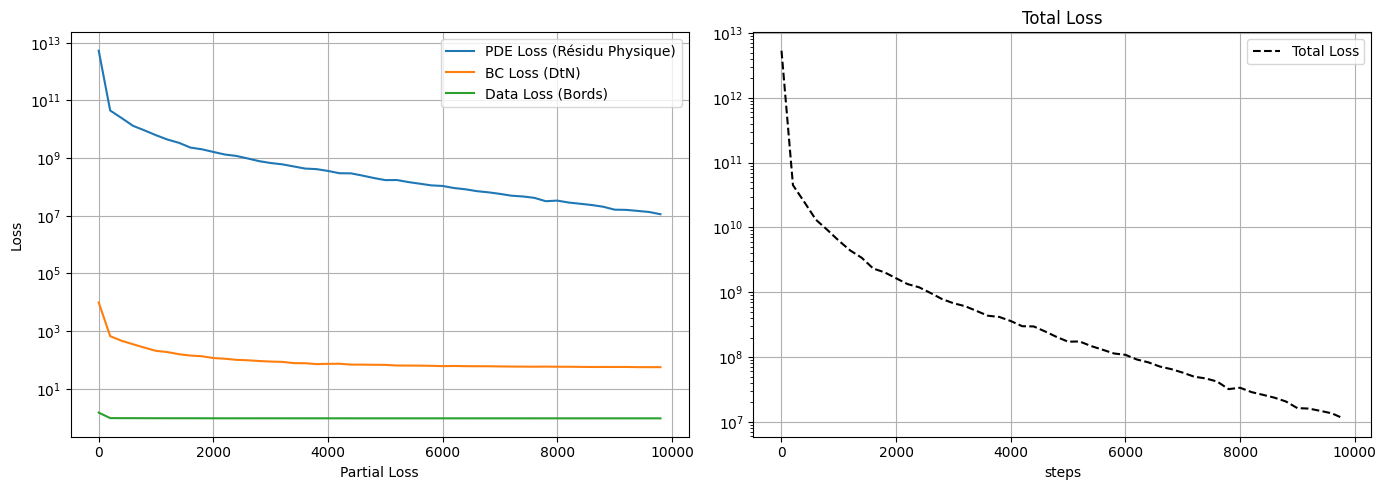

In [10]:
train_loss_arr = np.array(train_loss)
pde_losses = train_loss_arr[:, 0]
dtn_losses = train_loss_arr[:, 1]
data_losses = train_loss_arr[:, 2]
total_losses = pde_losses + dtn_losses + data_losses

x_axis = eval_interval * np.arange(len(train_loss))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(x_axis, pde_losses, label="PDE Loss (Résidu Physique)")
ax1.semilogy(x_axis, dtn_losses, label="BC Loss (DtN)")
ax1.semilogy(x_axis, data_losses, label="Data Loss (Bords)")

ax2.semilogy(x_axis, total_losses, label="Total Loss", linestyle='--', color='black')

ax1.set_xlabel("Partial Loss")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper right")
ax1.grid(True)

ax2.set_title("Total Loss")
ax2.set_xlabel("steps")
ax2.legend(loc="upper right")
ax2.grid(True)

plt.tight_layout()
plt.savefig('fig/2D_Wave_guide_metrics.pdf')
plt.show()